# Tutorial 7 — SMARTS Substructure Search
**Author:** Himanshu Goel 

In cheminformatics, identifying substructures within molecules is crucial for drug discovery, toxicity prediction, and understanding molecular properties. SMARTS (SMILES Arbitrary Target Specification) is a powerful language that extends SMILES notation to allow for flexible pattern matching.

This tutorial will guide you through:
- Understanding SMARTS patterns for common functional groups
- Performing substructure searches on a small molecule library
- Visualizing matches with highlighted atoms
- Creating custom SMARTS queries

Let's start by setting up our environment and exploring SMARTS patterns!

In [ ]:
!pip install rdkit pandas -q

## SMARTS Patterns

SMARTS uses square brackets `[]` to specify atom properties. Here are some key symbols:

- `[CX3]` : Carbon with 3 connections (sp2)
- `[OX2H]` : Oxygen with 2 connections and 1 hydrogen (hydroxyl)
- `[NX3;H2]` : Nitrogen with 3 connections and 2 hydrogens (primary amine)
- `[SX4](=O)(=O)` : Sulfur with 4 connections, bonded to two oxygens with double bonds (sulfonyl)

The patterns dictionary below contains common functional groups. Each SMARTS string defines a specific substructure.

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import Image
import pandas as pd

# Define pharmacophore/functional group patterns using SMARTS
patterns = {
    "Carboxylic acid":     "[CX3](=O)[OX2H1]",      # -COOH group
    "Ester":               "[CX3](=O)[OX2][CX4]",   # -COOR group
    "Amide":               "[CX3](=O)[NX3H]",       # -CONH- group
    "Primary amine":       "[NX3;H2]",              # -NH2 group
    "Secondary amine":     "[NX3;H1;!$(NC=O)]",    # -NHR group (not amide)
    "Aromatic ring":       "c1ccccc1",              # Benzene ring
    "Hydroxyl":            "[OX2H]",                # -OH group
    "Sulfonamide":         "[NX3][SX4](=O)(=O)",   # -SO2NH- group
    "Halogen":             "[F,Cl,Br,I]",           # F, Cl, Br, or I
    "Nitro":               "[$([NX3](=O)=O),$([NX3+](=O)[O-])]",  # -NO2 group
    "Thiophene":           "c1ccsc1",               # Thiophene ring
    "Imidazole":           "c1cn[nH]c1",            # Imidazole ring
}

# Sample molecule library with SMILES strings
library = {
    "Aspirin":       "CC(=O)Oc1ccccc1C(=O)O",
    "Paracetamol":   "CC(=O)Nc1ccc(O)cc1",
    "Morphine":      "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",
    "Ciprofloxacin": "OC(=O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Metformin":     "CN(C)C(=N)NC(=N)N",
    "Furosemide":    "NS(=O)(=O)c1cc(C(=O)O)c(NCc2ccco2)cc1Cl",
    "Omeprazole":    "CC1=CN=C(CS(=O)c2nc3cc(OC)ccc3[nH]2)C(OC)=C1",
}

# Perform substructure search for each molecule and pattern
rows = []
for mol_name, smi in library.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Invalid SMILES for {mol_name}: {smi}")
        continue
    row = {"Molecule": mol_name}
    for pat_name, smarts in patterns.items():
        pat = Chem.MolFromSmarts(smarts)
        if pat is None:
            print(f"Invalid SMARTS for {pat_name}: {smarts}")
            continue
        matches = mol.GetSubstructMatches(pat)
        row[pat_name] = len(matches) if matches else 0
    rows.append(row)

# Create and display results DataFrame
df = pd.DataFrame(rows).set_index("Molecule")
print("Functional group analysis results:")
print(df.to_string())

Functional group analysis results:
               Carboxylic acid  Ester  Amide  Primary amine  Secondary amine  Aromatic ring  Hydroxyl  Sulfonamide  Halogen  Nitro  Thiophene  Imidazole
Molecule                                                                                                                                                
Aspirin                      1      0      0              0                0              1         1            0        0      0          0          0
Paracetamol                  0      0      1              0                0              1         1            0        0      0          0          0
Morphine                     0      0      0              0                0              2         2            0        0      0          0          0
Ciprofloxacin                1      0      0              0                1              1         1            0        1      0          0          0
Metformin                    0      0      0   

## Visualizing Molecules

Let's take a look at our molecule library:

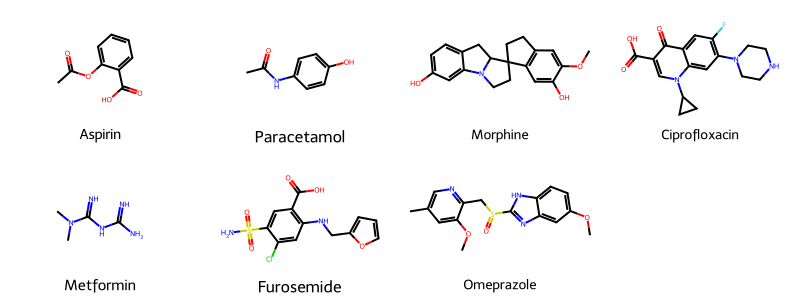

In [5]:
# Visualize the molecules
mols = [Chem.MolFromSmiles(smi) for smi in library.values()]
names = list(library.keys())
img = Draw.MolsToGridImage(mols, legends=names, molsPerRow=4, subImgSize=(200, 150))
display(img)

## Highlighting Substructure Matches

To better understand where functional groups are located in molecules, we can highlight the matching atoms. The `highlight_match` function below takes a molecule and a SMARTS pattern, finds all matches, and creates a 2D depiction with the matching atoms highlighted in red.

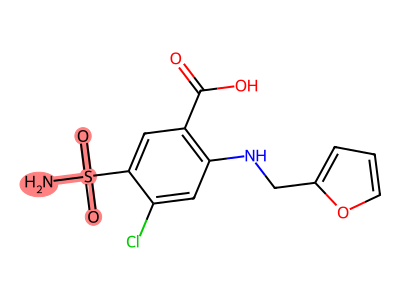

Highlighted sulfonamide group in Furosemide


In [7]:
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io

def highlight_match(mol, smarts, size=(400, 300)):
    """
    Highlight atoms and bonds matching a SMARTS pattern in a molecule.

    Parameters:
    - mol: RDKit molecule object
    - smarts: SMARTS string for the substructure
    - size: tuple for image size (width, height)

    Returns:
    - PIL Image object with highlighted matches
    """
    pat = Chem.MolFromSmarts(smarts)
    if pat is None:
        raise ValueError(f"Invalid SMARTS: {smarts}")

    matches = mol.GetSubstructMatches(pat)

    # Collect all atoms and bonds involved in matches
    hit_atoms = set()
    hit_bonds = set()
    for match in matches:
        hit_atoms.update(match)
        # Find bonds between matched atoms
        for b in mol.GetBonds():
            if b.GetBeginAtomIdx() in match and b.GetEndAtomIdx() in match:
                hit_bonds.add(b.GetIdx())

    # Create 2D drawing with highlights
    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    drawer.drawOptions().addAtomIndices = False
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(hit_atoms),
        highlightBonds=list(hit_bonds),
    )
    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))

# Example: Highlight sulfonamide group in Furosemide
mol_furo = Chem.MolFromSmiles(library["Furosemide"])
img = highlight_match(mol_furo, "[NX3][SX4](=O)(=O)")
img.save("sulfonamide_highlight.png")
display(img)
print("Highlighted sulfonamide group in Furosemide")

## More Examples

Let's explore a few more examples of substructure searching:

Molecules with aromatic rings: ['Aspirin', 'Paracetamol', 'Morphine', 'Ciprofloxacin', 'Furosemide', 'Omeprazole']


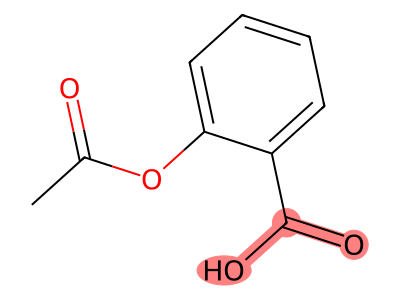

Highlighted carboxylic acid in Aspirin
Ciprofloxacin has 1 fluorine atom(s)


In [8]:
# Example 1: Find all molecules with aromatic rings
aromatic_mols = [name for name, smi in library.items()
                 if Chem.MolFromSmiles(smi).HasSubstructMatch(Chem.MolFromSmarts("c1ccccc1"))]
print("Molecules with aromatic rings:", aromatic_mols)

# Example 2: Highlight carboxylic acid in Aspirin
mol_asp = Chem.MolFromSmiles(library["Aspirin"])
img_asp = highlight_match(mol_asp, "[CX3](=O)[OX2H1]")
display(img_asp)
print("Highlighted carboxylic acid in Aspirin")

# Example 3: Count fluorine atoms in Ciprofloxacin
mol_cip = Chem.MolFromSmiles(library["Ciprofloxacin"])
fluorine_matches = mol_cip.GetSubstructMatches(Chem.MolFromSmarts("[F]"))
print(f"Ciprofloxacin has {len(fluorine_matches)} fluorine atom(s)")

## Creating Custom SMARTS Patterns

You can create your own SMARTS patterns for specific substructures. Here are some tips:

- Use `[C]` for any carbon, `[C;H3]` for methyl groups
- `[N+]` for positively charged nitrogen
- `[O-]` for negatively charged oxygen
- `~` for any bond (single, double, triple)
- `*` for any atom

Let's try searching for a custom pattern:

Molecules with pyridine-like rings: ['Ciprofloxacin', 'Omeprazole']


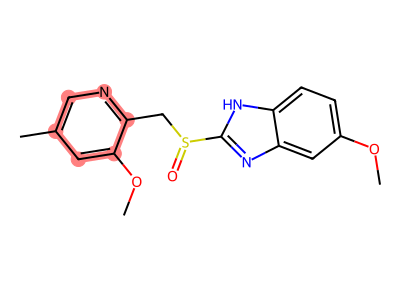

Highlighted pyridine-like ring in Omeprazole


In [9]:
# Custom pattern: Find molecules with pyridine-like rings (6-membered ring with one nitrogen)
pyridine_smarts = "c1ccccn1"
pyridine_pat = Chem.MolFromSmarts(pyridine_smarts)

pyridine_mols = []
for name, smi in library.items():
    mol = Chem.MolFromSmiles(smi)
    if mol.HasSubstructMatch(pyridine_pat):
        pyridine_mols.append(name)

print("Molecules with pyridine-like rings:", pyridine_mols)

# If found, highlight in one of them (Omeprazole has a pyridine-like structure)
if pyridine_mols:
    mol_omep = Chem.MolFromSmiles(library["Omeprazole"])
    img_omep = highlight_match(mol_omep, pyridine_smarts)
    display(img_omep)
    print("Highlighted pyridine-like ring in Omeprazole")

## Key Takeaways

- **SMARTS Syntax**: Uses square brackets for atom specifications, e.g., `[CX3]` for sp2 carbon, `[NX3;H2]` for primary amines
- **Recursive SMARTS**: `$()` allows recursive patterns, useful for complex groups like nitro: `[$([NX3](=O)=O),$([NX3+](=O)[O-])]`
- **Atom Maps**: In reaction SMARTS, `:1`, `:2` track atom correspondences between reactants and products
- **RDKit Functions**:
  - `HasSubstructMatch()`: Returns True/False if pattern exists
  - `GetSubstructMatches()`: Returns list of tuples with matching atom indices
- **Applications**: Toxicophore detection, scaffold hopping, virtual screening, retrosynthesis planning
- **Best Practices**: Always validate SMARTS patterns with `Chem.MolFromSmarts()`, handle invalid inputs gracefully

Try experimenting with different SMARTS patterns on your own molecules!